In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Playing with some distributions

(array([  5.,  40.,  98., 207., 286., 197., 113.,  41.,  12.,   1.]),
 array([ 53.8952027 ,  64.11357014,  74.33193757,  84.55030501,
         94.76867245, 104.98703989, 115.20540733, 125.42377477,
        135.64214221, 145.86050964, 156.07887708]),
 <BarContainer object of 10 artists>)

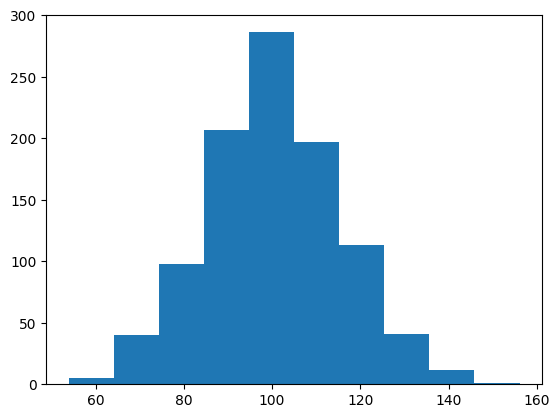

In [2]:
# Making a random uniform distribution
rng = np.random.default_rng()

uniform_array = rng.normal(loc=100, scale=15, size=1000)
plt.hist(uniform_array)

In [6]:
# some metrics

# sample mean
def mu_hat(dist):
    sum = np.sum(dist)
    return sum/len(dist)

# sample std
# You divide by n-1 to correct for downward bias and provide an unbiased estimate of the population variance
# downward bias is when expected value of an estimator is less than the actual population value
def sigma_hat(dist):
    sample_mean = mu_hat(dist)
    sqr = 0
    
    for i in dist:
        sqr += (i - sample_mean)**2

    return np.sqrt(sqr)/(len(dist)-1)

# Varience meaasures how far data spreads out from the mean
# Variance is defined as the expected value of the squared deviation from the mean
# you can also use np.var
def p_varience(dist):
    sample_mean = mu_hat(dist)
    sqr = 0
    for i in dist:
        sqr += (i - sample_mean)**2

    return (1/len(dist)) * sqr
    
def varience(dist):
    sample_mean = mu_hat(dist)
    sqr = 0
    for i in dist:
        sqr += (i - sample_mean)**2

    return (1/(len(dist)-1)) * sqr

In [8]:
print(f"Sample mean {mu_hat(uniform_array)}, Sample STD {sigma_hat(uniform_array)}, and varience {p_varience(uniform_array)}")

Sample mean 100.46782984408871, Sample STD 0.47739605828152004, and varience 227.4514103768035


The whole population varience vs sample varience is a little confusing so I'll explain it here. Population variance is used when you have the data for every single member of your entire group of interest. Sample variance is used when you have data for only a subset of that group and need to estimate the variance of the whole population. For example:
- When to use population varience: Calculating the variance of final scores for the exactly 30 students enrolled in a specific course
- Measuring the heights of 50 randomly selected redwood trees to estimate the variance in a protected forest

# Comparing Strategies Example

Here we will generate two distributions which represent the returns of two different trading strategies.
- A is the new strategy you came up with
- B is some older more basic strategy, like buying and holding

0.0019204204703028892


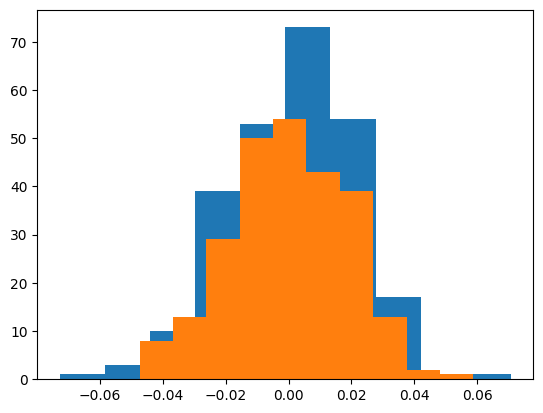

In [5]:
A = np.random.normal(0.001,0.02,252)
B = np.random.normal(0.0005,0.02,252)

plt.hist(A)
plt.hist(B)

mean_A = np.mean(A)
mean_B = np.mean(B)

diff = mean_A - mean_B

print(diff)

Now we can formulate the following:<br>
Null Hypothesis: $$H_0:\mu_A = \mu_B$$
Alternative: $$H_1​:\mu_A​>\mu_B​$$

In [21]:
# some more metrics

# t-stat is used in hypothesis testing to see weither to support a claim or not
# in quant finance it is used to see if a trading strategy has a statistically significant edge
# use population varience in this instance
# a t-stat greater than 2 means the strategy is statistically significant

# p-value, similarly to t-stat is a statistical measurement used to determine the validity of a hypothesis. It quantifies the probability of obtaining your observed results
# you want a p-value of 0.05 or less
def t_stat(dist1, dist2):
    mean1, mean2 = mu_hat(dist1), mu_hat(dist2)
    var1, var2 = p_varience(dist1), p_varience(dist2)
    n1, n2 = len(dist1), len(dist2)
    t_stat = 0
    p_val = 0

    # test if we use Student's t-test or not
    if var1 == var2:
        # student's t-test
        pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
        t_stat = (mean1 - mean2) / np.sqrt(pooled_var * (1/n1 + 1/n2))
        _, p_val = stats.ttest_ind(dist1, dist2, equal_var=True)
    else:
        # welch's t-test
        t_stat = (mean1 - mean2) / np.sqrt((var1 / n1) + (var2 / n2))
        _, p_val = stats.ttest_ind(dist1, dist2, equal_var=False)
    return t_stat, p_val

# Sharpe ratio measures how well an investment performs compared to its risk
# similar to t-stat it shows if the strategy has a statistically significant edge
# A Sharpe ratio above 1 is acceptable
def sharpe(dist):
    return mu_hat(dist) / (sigma_hat(dist) * np.sqrt(len(dist)))

# Volatility is a measure of how much an asset's price fluctuates over time, which is actually the standard deviation
# you can also use relative volatility which compares an asset's volatility to the overall market, usually the SnP 500

In [22]:
t_s, p_val = t_stat(A,B)
sharpe_1, sharpe_2 = sharpe(A), sharpe(B)
print(f"We found that the t-stat is {t_s} and the sharpe ratio for strategy A is {sharpe_1} while the sharpe ratio for strategy B is {sharpe_2}")
print(f"We also can find the p_value to be {p_val}")

We found that the t-stat is 1.1258565908109162 and the sharpe ratio for strategy A is 0.08885600098829863 while the sharpe ratio for strategy B is -0.0091099878310721
We also can find the p_value to be 0.26171108246480346


As we can see, strategy A does perform better based on the higher sharpe ratio. But the t-stat is under 2 and the sharpe ratio is only 0.08. The p value is also too high.